In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

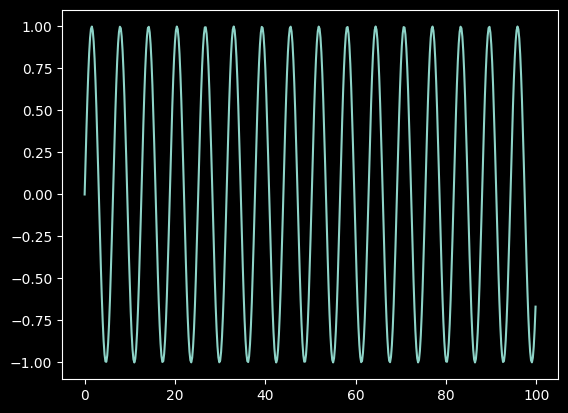

In [2]:
x = np.arange(0, 100, 0.2)
y = np.sin(x)
plt.plot(x, y)


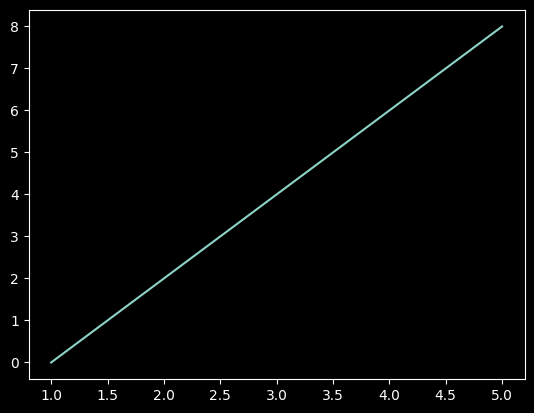

In [3]:
x = [1, 2, 3, 4, 5]
y = [0, 2, 4, 6, 8]
plt.plot(x, y)

In [4]:
df['job_posted_month'] = df['job_posted_date'].dt.month
df['job_posted_year'] = df['job_posted_date'].dt.year

df[['job_posted_month', 'job_posted_year']].head(10)



,job_posted_month,job_posted_year
0,6,2023
1,1,2023
2,10,2023
3,7,2023
4,8,2023
5,11,2023
6,3,2023
7,12,2023
8,6,2023
9,4,2023


In [5]:
month_counts = df['job_posted_month'].value_counts()
month_counts


job_posted_month
1     91822
8     75162
10    66611
2     64578
11    64450
3     64084
7     63777
4     62919
9     62359
6     61572
12    56303
5     52104
Name: count, dtype: int64

In [6]:
year_counts = df['job_posted_year'].value_counts()
year_counts

job_posted_year
2023    785741
Name: count, dtype: int64

In [7]:
month_counts = month_counts.sort_index()
month_counts

job_posted_month
1     91822
2     64578
3     64084
4     62919
5     52104
6     61572
7     63777
8     75162
9     62359
10    66611
11    64450
12    56303
Name: count, dtype: int64

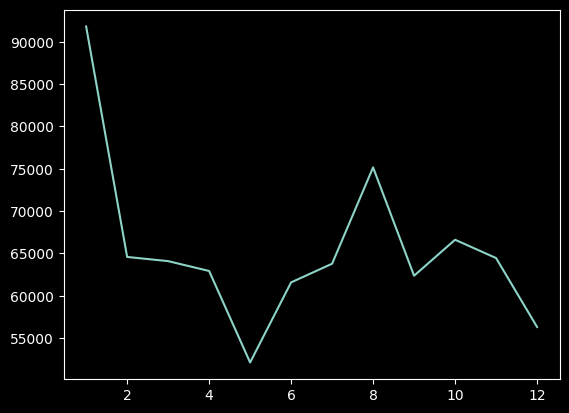

In [8]:
plt.plot(month_counts.index, month_counts.values)

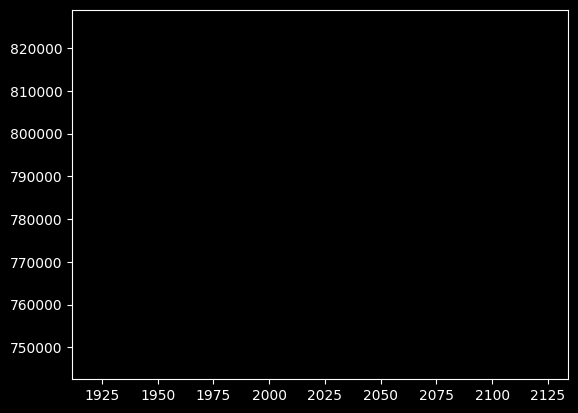

In [9]:
plt.plot(year_counts.index, year_counts.values)

In [10]:
job_title_counts = df.job_title_short.value_counts()
job_title_counts

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

<BarContainer object of 10 artists>

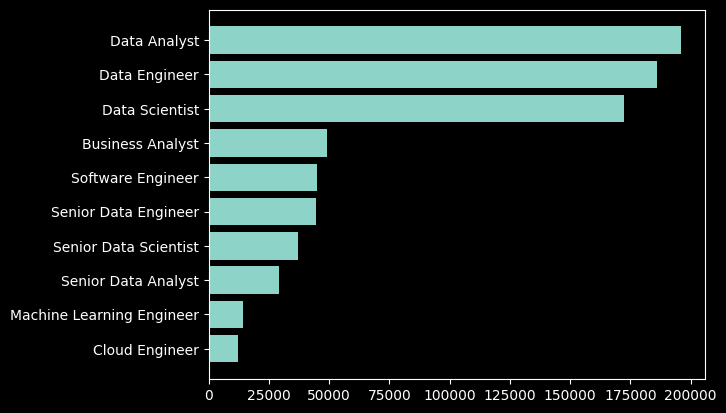

In [11]:
job_title_counts = job_title_counts.sort_values(ascending=True)
plt.barh(job_title_counts.index, job_title_counts.values)

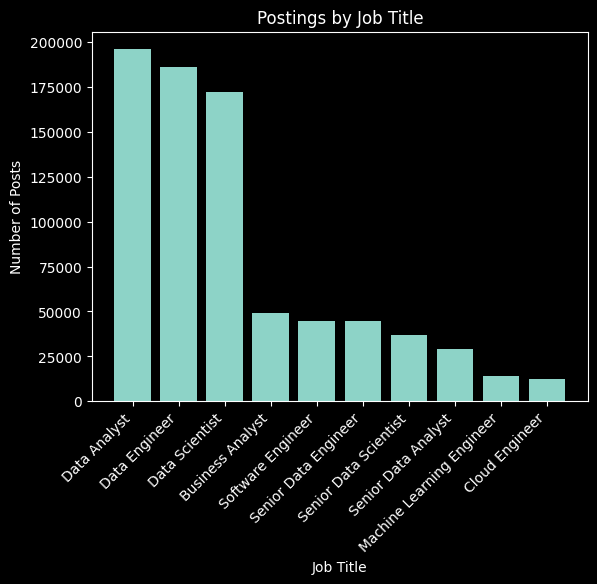

In [12]:
job_title_counts = job_title_counts.sort_values(ascending=False)
plt.bar(job_title_counts.index, job_title_counts.values)
plt.title('Postings by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='job_title_short'>

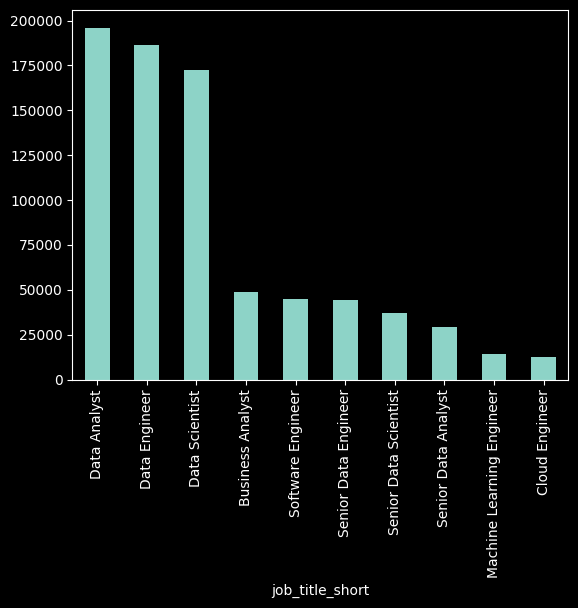

In [13]:
job_title_counts.plot(kind='bar')

<Axes: xlabel='job_posted_month', ylabel='salary_year_avg'>

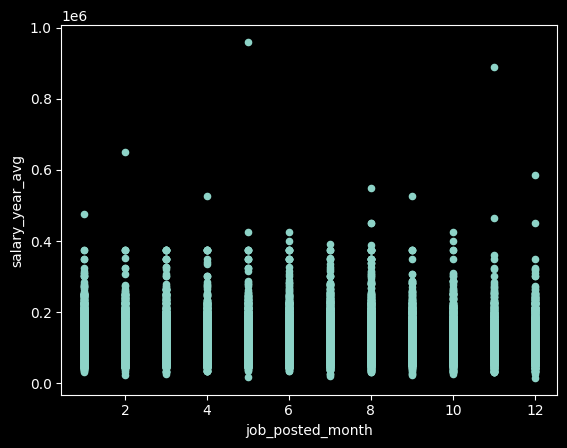

In [15]:
df.plot(x='job_posted_month', y='salary_year_avg', kind='scatter')

In [19]:
job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

<Axes: xlabel='job_title_short'>

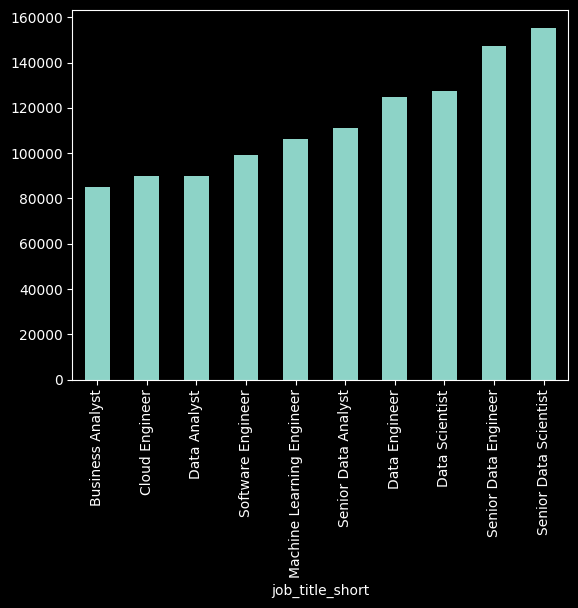

In [20]:
job_salary.plot(kind='bar')